<a href="https://colab.research.google.com/github/isadetbo68/USA-Real-Estate-Dataset_69/blob/Dev-ice/lab15_project_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: [ชื่อโครงงาน]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: นายอิศม์เดช บุญจรัส (68114540753)

- สมาชิกที่ 2: นายไชยวัฒน์ ทำดี (68114540155)

**Dataset:** [ชื่อ dataset, แหล่งที่มา, URL]

**Problem Statement:** [อธิบาย 2-3 ประโยคว่าปัญหาคืออะไร ทำไมถึงสนใจ dataset นี้]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ⬜ |
| CLO2 (Statistical Learning) | Part 3 | ⬜ |
| CLO3 (Regression/Classification) | Part 4 | ⬜ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [9]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [5]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
df = pd.read_csv('realtor-data.zip.csv')

# แสดงข้อมูลพื้นฐาน
print(f'Shape ของข้อมูลทั้งหมด: {df.shape}')
print(f'\nรายชื่อคอลัมน์ทั้งหมด:\n{df.columns.tolist()}')
print(f'\nชนิดข้อมูลของแต่ละคอลัมน์:\n{df.dtypes}')
print(f'\nจำนวน Missing Values ในแต่ละคอลัมน์:\n{df.isnull().sum()}')
df.head()

Shape ของข้อมูลทั้งหมด: (102336, 12)

รายชื่อคอลัมน์ทั้งหมด:
['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']

ชนิดข้อมูลของแต่ละคอลัมน์:
brokered_by       float64
status             object
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city               object
state              object
zip_code          float64
house_size        float64
prev_sold_date     object
dtype: object

จำนวน Missing Values ในแต่ละคอลัมน์:
brokered_by          73
status                0
price                18
bed               16096
bath              15459
acre_lot          25658
street              357
city                 22
state                 0
zip_code             32
house_size        31996
prev_sold_date    49200
dtype: int64


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


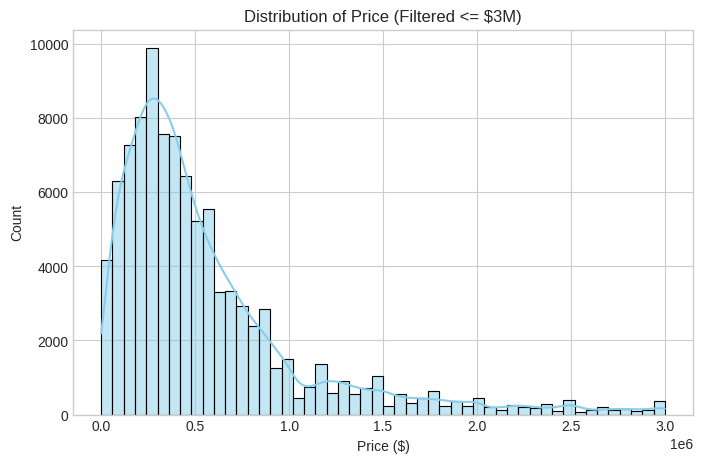

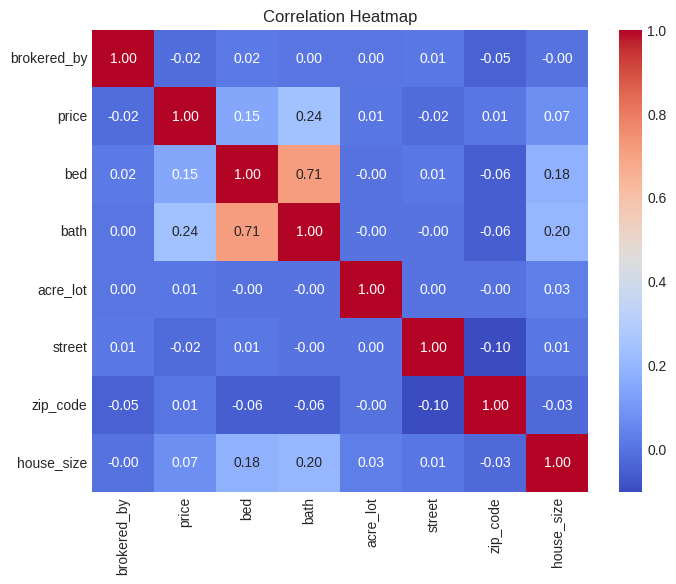

In [12]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
df.describe()
# 2. Distribution plot ของ target
df_filtered = df[(df['price'] > 0) & (df['price'] <= 3000000)]

plt.figure(figsize=(8, 5))
sns.histplot(df_filtered['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Price (Filtered <= $3M)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()
# 3. Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
pass

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** [อธิบาย 2-3 ประโยคว่าทำไมถึงเลือก task นี้ และ insight ที่คาดว่าจะได้]

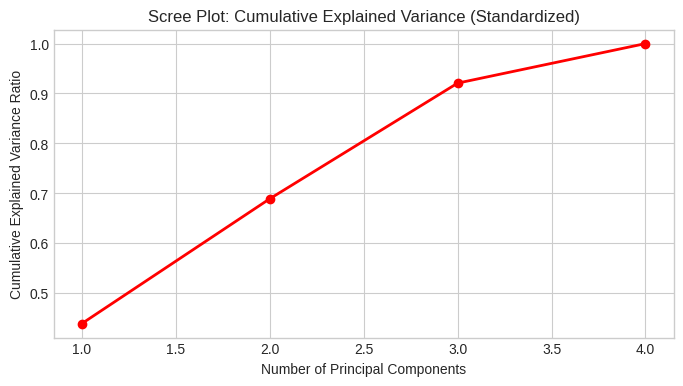

Explained Variance Ratio ของแต่ละ PC: [0.4391 0.25   0.2317 0.0792]
ความแปรปรวนสะสมของ 2 PCs แรก: 68.91%


In [16]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: ทำ PCA เพื่อลดมิติของข้อมูลด้วย Eigendecomposition

# TODO: เขียน code ที่นี่
# ตัวอย่างสำหรับ PCA:

# 1. เลือกคอลัมน์ตัวเลขและลบค่า Missing
feature_cols = ['bed', 'bath', 'acre_lot', 'house_size']
df_pca = df[feature_cols].dropna()

# 2. Standardize ข้อมูล (ให้ทุกตัวแปรมี Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca.values)

# 3. คำนวณ Covariance Matrix C
N = len(X_scaled)
C = (1 / (N - 1)) * (X_scaled.T @ X_scaled)

# 4. หา Eigenvalues และ Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(C)

# 5. เรียงลำดับจากมากไปน้อย
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 6. คำนวณ Explained Variance Ratio
explained_variance = eigenvalues / np.sum(eigenvalues)
cum_explained_variance = np.cumsum(explained_variance)

# 7. Plot Scree Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigenvalues) + 1), cum_explained_variance, 'ro-', linewidth=2)
plt.title('Scree Plot: Cumulative Explained Variance (Standardized)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

print("Explained Variance Ratio ของแต่ละ PC:", explained_variance.round(4))
print(f"ความแปรปรวนสะสมของ 2 PCs แรก: {cum_explained_variance[1]*100:.2f}%")
pass

**Insight จาก CLO1 Analysis:**
> [จากการทำ PCA เพื่อลดมิติข้อมูลของ Features (bed, bath, acre_lot, house_size) พบว่า Principal Components 2 ตัวแรก (PC1 และ PC2) สามารถอธิบายความแปรปรวนสะสมของข้อมูลได้รวม 68.91% (โดย PC1 อธิบายได้ 43.91% และ PC2 อธิบายได้ 25.00%)   ซึ่งถือว่าเพียงพอในการรักษาข้อมูลส่วนใหญ่ไว้ได้ การแปลงข้อมูลด้วยวิธีนี้ช่วยให้เราลดจำนวนตัวแปรลงเหลือเพียง 2 มิติหลักได้โดยไม่เสียรายละเอียดสำคัญ และยังช่วยลดปัญหาความสัมพันธ์กันเองระหว่าง Features (Multicollinearity) ก่อนนำไปใช้ใน Regression Model]

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

In [ ]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. Plot distributions
# 2. Correlation analysis กับ target
# 3. แสดง U-curve ของ Train/Test MSE (polynomial degree หรือ model complexity)
pass

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ⬜ Regression  ⬜ Classification

In [ ]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 1 คืออะไร]

# TODO:
# X_train, X_test, y_train, y_test = train_test_split(...)
# model1 = ???
# model1.fit(X_train, y_train)
# ...
pass

In [ ]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 2 คืออะไร]

# TODO:
# model2 = ???
# ...
pass

**สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: ___ | | | |
| Model 2: ___ | | | |

**Insight:**
> [เปรียบเทียบ: Model ไหนดีกว่า? ทำไม? มี overfitting/underfitting ไหม?]

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

In [ ]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
# models = {
#     'Model 1': ???,
#     'Model 2': ???,
#     'Model 3': ???,
# }
#
# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
#     cv_mse = -scores.mean()
#     print(f'{name}: CV MSE = {cv_mse:.4f}')
pass

**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**
> [อธิบาย: CV MSE ต่ำสุดคือเท่าไหร่? มี overfitting ไหม? เชื่อมกับ Bias-Variance อย่างไร?]

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- CLO1: ...
- CLO2: ...
- CLO3: ...
- CLO4: ...

**6.2 Limitations:**
> [อะไรที่ทำไม่ได้หรือมีข้อจำกัด เช่น dataset เล็กเกินไป, missing values, features ไม่ครบ]

**6.3 ขั้นตอนต่อไป (Future Work):**
> [ถ้ามีเวลามากกว่านี้จะทำอะไรต่อ]

**6.4 Connection กับ Topics ในวิชา:**
> [เชื่อมกับ Week ต่างๆ ที่เรียนมา ว่า concept ไหนนำมาใช้จริงในโครงงานนี้]

---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล / tools / references ที่ใช้]